In [1]:
import sys, os, glob
import numpy as np
import matplotlib.pyplot as plt

# the chapter programs live in BookPrograms/chapterNN and the appendix
# programs in BookPrograms/appendixX; put them all on the path
for _pattern in ("chapter*", "appendix*"):
    for _d in sorted(glob.glob(os.path.join("..", "BookManybody",
                                            "BookPrograms", _pattern))):
        if _d not in sys.path:
            sys.path.insert(0, _d)
import atoms

np.set_printoptions(precision=6, suppress=True, linewidth=120)

In [2]:
for key in ((1, 1, 1, 1), (1, 2, 1, 2), (1, 1, 2, 2), (1, 3, 3, 1), (2, 3, 3, 2), (3, 3, 3, 3)):
    exact = 2.0 * atoms.RADIAL[key]
    numeric = atoms.radial_quadrature(*key, Z=2.0, points=6000)
    print(f"<{key[0]}{key[1]}|V|{key[2]}{key[3]}> = {exact:.8f}   quadrature {numeric:.8f}"
          f"   difference {abs(exact - numeric):.1e}")
print()
print("spin-orbital index p = 2(n-1) + s:", ", ".join(f"{p}={atoms.Atom(2, 2).label(p)}" for p in range(6)))

<11|V|11> = 1.25000000   quadrature 1.25000833   difference 8.3e-06
<12|V|12> = 0.41975309   quadrature 0.41975391   difference 8.2e-07


<11|V|22> = 0.04389575   quadrature 0.04389657   difference 8.2e-07
<13|V|31> = 0.01153564   quadrature 0.01153588   difference 2.4e-07


<23|V|32> = 0.01495204   quadrature 0.01495208   difference 3.9e-08
<33|V|33> = 0.13281250   quadrature 0.13281252   difference 1.6e-08

spin-orbital index p = 2(n-1) + s: 0=1s+, 1=1s-, 2=2s+, 3=2s-, 4=3s+, 5=3s-


In [3]:
he = atoms.Atom(Z=2, N=2)
be = atoms.Atom(Z=4, N=4)
print("helium:  <1s+ 1s-|v|1s+ 1s->_AS =", f"{he.v_as[0, 1, 0, 1]:.6f}",
      "  <1s+ 1s+|v|1s+ 1s+>_AS =", f"{he.v_as[0, 0, 0, 0]:.6f}")
print("beryllium: <1s+ 2s+|v|1s+ 2s+>_AS =", f"{be.v_as[0, 2, 0, 2]:.6f}",
      "  <1s+ 2s-|v|1s+ 2s->_AS =", f"{be.v_as[0, 3, 0, 3]:.6f}")

helium:  <1s+ 1s-|v|1s+ 1s->_AS = 1.250000   <1s+ 1s+|v|1s+ 1s+>_AS = 0.000000
beryllium: <1s+ 2s+|v|1s+ 2s+>_AS = 0.751715   <1s+ 2s-|v|1s+ 2s->_AS = 0.839506


In [4]:
for atom, name in ((he, "helium"), (be, "beryllium")):
    alpha, beta = atom.reference_energy_coefficients()
    H = atom.fock_space_hamiltonian()
    print(f"{name}: |c> = {atom.determinant_label(atom.reference)}")
    print(f"   E[Phi_0] = {alpha:+.6f} Z^2 {beta:+.6f} Z = {atom.reference_energy():.6f}")
    print(f"   64 x 64 Hamiltonian: symmetric {np.allclose(H, H.T)}, "
          f"<c|H|c> = {H[atom.reference, atom.reference]:.6f}, commutes with N: "
          f"{np.allclose(H @ np.diag([bin(k).count('1') for k in range(64)]), np.diag([bin(k).count('1') for k in range(64)]) @ H)}")
    states, pairs = atom.singles()
    print("   1p-1h states with M_S = 0:",
          ", ".join(f"a+_{atom.label(m)} a_{atom.label(i)}|c>" for m, i in pairs))

helium: |c> = |1s+ 1s->
   E[Phi_0] = -1.000000 Z^2 +0.625000 Z = -2.750000
   64 x 64 Hamiltonian: symmetric True, <c|H|c> = -2.750000, commutes with N: True
   1p-1h states with M_S = 0: a+_2s+ a_1s+|c>, a+_3s+ a_1s+|c>, a+_2s- a_1s-|c>, a+_3s- a_1s-|c>
beryllium: |c> = |1s+ 1s- 2s+ 2s->
   E[Phi_0] = -1.250000 Z^2 +1.571001 Z = -13.715996
   64 x 64 Hamiltonian: symmetric True, <c|H|c> = -13.715996, commutes with N: True
   1p-1h states with M_S = 0: a+_3s+ a_1s+|c>, a+_3s- a_1s-|c>, a+_3s+ a_2s+|c>, a+_3s- a_2s-|c>


In [5]:
for atom, name in ((he, "helium"), (be, "beryllium")):
    H = atom.fock_space_hamiltonian()
    E, C, M, states, pairs = atom.cis(H)
    M2, _, _ = atom.cis_closed_form()
    print(f"{name}: CIS matrix (hydrogenic basis)")
    print(np.round(M, 5))
    print(f"   closed form vs Fock-space projection: {np.abs(M - M2).max():.1e}")
    print(f"   eigenvalues: {np.round(E, 5)}")
    print(f"   E_CIS - E[Phi_0] = {E[0] - atom.reference_energy():+.6f}")
    print()

helium: CIS matrix (hydrogenic basis)
[[-2.75     0.17871  0.08792  0.17871  0.08792]
 [ 0.17871 -2.08025  0.10105  0.0439   0.02245]
 [ 0.08792  0.10105 -2.02325  0.02245  0.01154]
 [ 0.17871  0.0439   0.02245 -2.08025  0.10105]
 [ 0.08792  0.02245  0.01154  0.10105 -2.02325]]
   closed form vs Fock-space projection: 4.4e-16
   eigenvalues: [-2.83865 -2.16988 -2.13619 -1.98905 -1.82322]
   E_CIS - E[Phi_0] = -0.088648

beryllium: CIS matrix (hydrogenic basis)
[[-13.716     0.18915   0.18915   0.44519   0.44519]
 [  0.18915  -9.65515   0.02307  -0.39303   0.00844]
 [  0.18915   0.02307  -9.65515   0.00844  -0.39303]
 [  0.44519  -0.39303   0.00844 -13.68839   0.0299 ]
 [  0.44519   0.00844  -0.39303   0.0299  -13.68839]]
   closed form vs Fock-space projection: 7.1e-15
   eigenvalues: [-14.36211 -13.7578  -13.05941  -9.63871  -9.58503]
   E_CIS - E[Phi_0] = -0.646112



In [6]:
for atom, name in ((he, "helium"), (be, "beryllium")):
    H = atom.fock_space_hamiltonian()
    E, V, states = atom.fci(H)
    print(f"{name}: FCI in the M_S = 0 sector, dimension {len(states)}")
    print("   determinants:", ", ".join(atom.determinant_label(s) for s in states))
    print(f"   E_0 = {E[0]:.6f}; excitation energies "
          + ", ".join(f"{e - E[0]:.4f}" for e in E[1:]))
    weights = V[:, 0] ** 2
    print("   ground-state weights:", ", ".join(f"{atom.determinant_label(s)} {w:.4f}"
                                                for s, w in zip(states, weights) if w > 1e-3))

helium: FCI in the M_S = 0 sector, dimension 9
   determinants: |1s+ 1s->, |1s- 2s+>, |1s+ 2s->, |2s+ 2s->, |1s- 3s+>, |2s- 3s+>, |1s+ 3s->, |2s+ 3s->, |3s+ 3s->
   E_0 = -2.839449; excitation energies 0.6696, 0.7031, 0.8504, 1.0144, 2.1205, 2.2705, 2.3210, 2.5297
   ground-state weights: |1s+ 1s-> 0.9090, |1s- 2s+> 0.0403, |1s+ 2s-> 0.0403, |1s- 3s+> 0.0050, |1s+ 3s-> 0.0050
beryllium: FCI in the M_S = 0 sector, dimension 9
   determinants: |1s+ 1s- 2s+ 2s->, |1s+ 1s- 2s- 3s+>, |1s- 2s+ 2s- 3s+>, |1s+ 1s- 2s+ 3s->, |1s+ 2s+ 2s- 3s->, |1s+ 1s- 3s+ 3s->, |1s- 2s+ 3s+ 3s->, |1s+ 2s- 3s+ 3s->, |2s+ 2s- 3s+ 3s->
   E_0 = -14.512907; excitation energies 0.7489, 0.8677, 1.7162, 4.6672, 4.8496, 5.3815, 5.4867, 10.8905
   ground-state weights: |1s+ 1s- 2s+ 2s-> 0.3358, |1s+ 1s- 2s- 3s+> 0.2553, |1s- 2s+ 2s- 3s+> 0.0039, |1s+ 1s- 2s+ 3s-> 0.2553, |1s+ 2s+ 2s- 3s-> 0.0039, |1s+ 1s- 3s+ 3s-> 0.1421, |1s- 2s+ 3s+ 3s-> 0.0018, |1s+ 2s- 3s+ 3s-> 0.0018


helium: converged in 17 iterations
   E_HF = -2.83109609   epsilon = [-0.888475  0.039422  0.439516]
   first iteration: E = -2.829193, epsilon = [-0.783288  0.039634  0.453456]
   chapter-6 SelfConsistentField: E = -2.83109609, Brillouin max |f_ai| = 8.3e-14
beryllium: converged in 18 iterations
   E_HF = -14.50825244   epsilon = [-4.686982 -0.305266  0.811124]
   first iteration: E = -14.499823, epsilon = [-3.950699 -0.10404   0.865689]


   chapter-6 SelfConsistentField: E = -14.50825244, Brillouin max |f_ai| = 2.1e-14


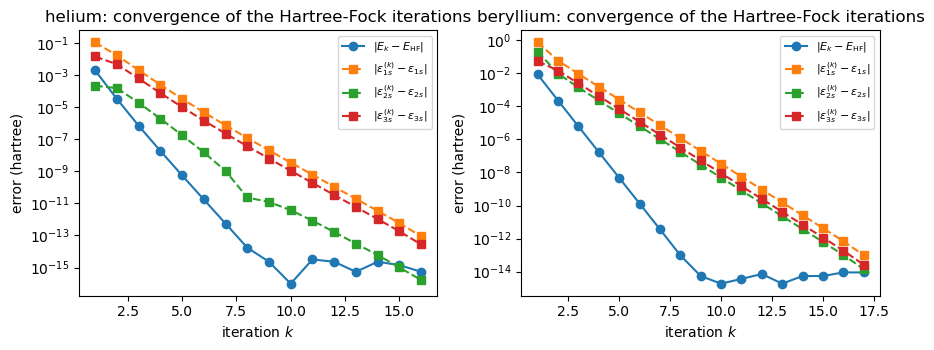

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.6))
for ax, atom, name in zip(axes, (he, be), ("helium", "beryllium")):
    hf = atom.hartree_fock(tol=1e-13)
    E, eps = hf["energy"], hf["eps_spatial"]
    print(f"{name}: converged in {hf['iterations']} iterations")
    print(f"   E_HF = {E:.8f}   epsilon = {np.round(eps, 6)}")
    print(f"   first iteration: E = {hf['history'][0][1]:.6f}, epsilon = {np.round(hf['history'][0][2], 6)}")
    hf6 = atom.hartree_fock_chapter6()
    if hf6 is not None:
        print(f"   chapter-6 SelfConsistentField: E = {hf6['energy']:.8f}, "
              f"Brillouin max |f_ai| = {hf6['brillouin']:.1e}")
    history = hf["history"][:-1]                 # the last entry is the converged one itself
    iterations = [k for k, _, _ in history]
    ax.semilogy(iterations, [abs(e - E) + 1e-16 for _, e, _ in history], "o-", label=r"$|E_k-E_{\rm HF}|$")
    for n in range(3):
        ax.semilogy(iterations, [abs(ep[n] - eps[n]) + 1e-16 for _, _, ep in history], "s--",
                    label=rf"$|\varepsilon_{{{n+1}s}}^{{(k)}}-\varepsilon_{{{n+1}s}}|$")
    ax.set_xlabel("iteration $k$")
    ax.set_ylabel("error (hartree)")
    ax.set_title(f"{name}: convergence of the Hartree-Fock iterations")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [8]:
for atom, name in ((he, "helium"), (be, "beryllium")):
    hf = atom.hartree_fock()
    h, v = atom.transform(hf["C"])
    H_hf = atom.fock_space_hamiltonian(h, v)
    E, _, M, _, pairs = atom.cis(H_hf)
    E_fci_hf = atom.fci(H_hf)[0]
    E_fci = atom.fci()[0]
    print(f"{name}: CIS in the HF basis")
    print(f"   |<c|H|Phi_i^m>| = {np.abs(M[0, 1:]).max():.1e}   (Brillouin)")
    print(f"   lowest CIS eigenvalue {E[0]:.8f} = E_HF {hf['energy']:.8f}")
    print(f"   FCI: hydrogenic basis {E_fci[0]:.8f}, HF basis {E_fci_hf[0]:.8f}")
    print(f"   correlation energy E_FCI - E_HF = {E_fci[0] - hf['energy']:+.6f}")

helium: CIS in the HF basis
   |<c|H|Phi_i^m>| = 8.4e-14   (Brillouin)
   lowest CIS eigenvalue -2.83109609 = E_HF -2.83109609
   FCI: hydrogenic basis -2.83944883, HF basis -2.83944883
   correlation energy E_FCI - E_HF = -0.008353
beryllium: CIS in the HF basis
   |<c|H|Phi_i^m>| = 2.1e-14   (Brillouin)
   lowest CIS eigenvalue -14.50825244 = E_HF -14.50825244
   FCI: hydrogenic basis -14.51290749, HF basis -14.51290749
   correlation energy E_FCI - E_HF = -0.004655


In [9]:
results = {}
for atom, name in ((he, "helium"), (be, "beryllium")):
    hf = atom.hartree_fock()
    res = atom.tda_rpa(hf)
    A_dc, B_dc, _ = atom.double_commutators(hf, res["pairs"])
    results[name] = (atom, hf, res)
    print(f"{name}: {len(res['pairs'])} spin-conserving particle-hole pairs")
    print(f"   closed-form A vs double commutator: {np.abs(res['A'] - A_dc).max():.1e}, "
          f"B: {np.abs(res['B'] - B_dc).max():.1e}")
    print("   A =\n", np.round(res["A"], 5))
    print("   B =\n", np.round(res["B"], 5))
    print(f"   stability: min eig(A-B) = {res['stability'][0]:.4f}, min eig(A+B) = {res['stability'][1]:.4f}, "
          f"imaginary RPA roots: {res['n_imag']}")
    print(f"   TDA: {np.round(res['tda'], 5)}")
    print(f"   RPA: {np.round(res['rpa'], 5)}")
    E_fci = atom.fci()[0]
    print(f"   FCI: {np.round(E_fci[1:] - E_fci[0], 5)}")
    print(f"   E_corr(RPA) = {res['ecorr']:+.6f}; E_HF + E_corr = {hf['energy'] + res['ecorr']:.6f}, "
          f"E_FCI = {E_fci[0]:.6f}, E_FCI - E_HF = {E_fci[0] - hf['energy']:+.6f}")
    full = atom.tda_rpa(hf, spin_conserving=False)
    print(f"   TDA with all {len(full['pairs'])} pairs (spin flips included): {np.round(full['tda'], 5)}")
    print()

helium: 4 spin-conserving particle-hole pairs
   closed-form A vs double commutator: 8.8e-14, B: 2.8e-17
   A =
 [[ 0.75419  0.05889  0.00461 -0.02359]
 [ 0.05889  0.93868 -0.02359  0.1279 ]
 [ 0.00461 -0.02359  0.75419  0.05889]
 [-0.02359  0.1279   0.05889  0.93868]]
   B =
 [[ 0.       0.       0.00461 -0.02359]
 [-0.      -0.      -0.02359  0.1279 ]
 [ 0.00461 -0.02359  0.       0.     ]
 [-0.02359  0.1279  -0.      -0.     ]]
   stability: min eig(A-B) = 0.7370, min eig(A+B) = 0.6034, imaginary RPA roots: 0
   TDA: [0.69221 0.75481 0.86815 1.07058]
   RPA: [0.68595 0.75396 0.86303 1.06299]
   FCI: [0.66957 0.70313 0.8504  1.01443 2.12054 2.2705  2.32096 2.52967]
   E_corr(RPA) = -0.009914; E_HF + E_corr = -2.841010, E_FCI = -2.839449, E_FCI - E_HF = -0.008353
   TDA with all 8 pairs (spin flips included): [0.69221 0.69221 0.69221 0.75481 0.86815 0.86815 0.86815 1.07058]

beryllium: 4 spin-conserving particle-hole pairs
   closed-form A vs double commutator: 7.1e-14, B: 1.4e-17
   

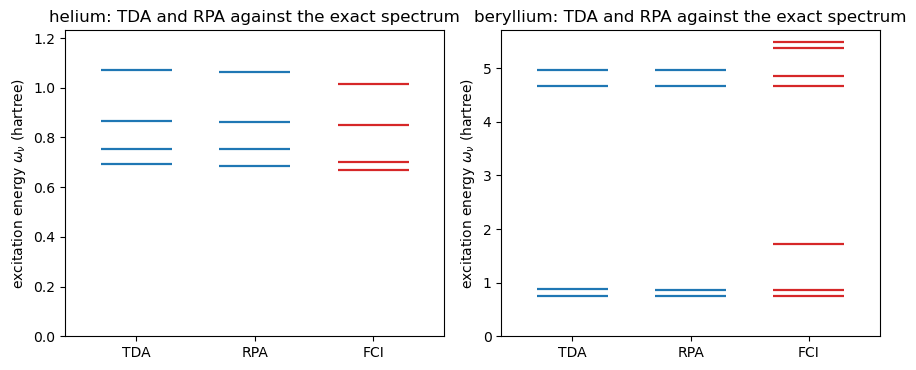

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.8))
for ax, name in zip(axes, ("helium", "beryllium")):
    atom, hf, res = results[name]
    E_fci = atom.fci()[0]
    columns = [("TDA", res["tda"]), ("RPA", res["rpa"]), ("FCI", E_fci[1:] - E_fci[0])]
    for x, (label, omegas) in enumerate(columns):
        for w in omegas:
            ax.hlines(w, x - 0.3, x + 0.3, color="C0" if label != "FCI" else "C3", lw=1.6)
    ax.set_xticks(range(3))
    ax.set_xticklabels([c[0] for c in columns])
    ax.set_ylabel(r"excitation energy $\omega_\nu$ (hartree)")
    ax.set_title(f"{name}: TDA and RPA against the exact spectrum")
    ax.set_xlim(-0.6, 2.6)
    ax.set_ylim(0.0, 1.15 * res["tda"].max())    # the exact doubles above this are off scale
plt.tight_layout()
plt.show()

helium-like:  Z, E_FCI, and E - E_FCI for the reference, HF, CIS and HF+RPA (millihartree)
     2     -2.83945      89.449     8.353     0.800    -1.561
     3     -7.19898      73.980     4.080     0.944    -0.569
     4    -13.56743      67.430     2.814     0.978    -0.305
     5    -21.93889      63.886     2.257     0.990    -0.198
     6    -32.31168      61.677     1.953     0.994    -0.143
     7    -44.68517      60.170     1.764     0.996    -0.111
     8    -59.05908      59.078     1.636     0.996    -0.090
     9    -75.43325      58.251     1.543     0.996    -0.075
    10    -93.80760      57.602     1.474     0.996    -0.064


beryllium-like:  Z, E_FCI, and E - E_FCI for the reference, HF, CIS and HF+RPA (millihartree)
     3     -7.35608     819.082     4.566   204.862    -0.638
     4    -14.51291     796.912     4.655   150.800    -0.416
     5    -24.14038     745.380     5.257   101.362    -0.273
     6    -36.26515     691.152     5.146    65.936    -0.184
     7    -50.89701     644.019     4.547    42.992    -0.139
     8    -68.03770     605.713     3.863    28.619    -0.113
     9    -87.68615     575.156     3.268    19.588    -0.095
    10   -109.84072     550.727     2.795    13.794    -0.080
    11   -134.49998     530.992     2.428     9.972    -0.068
    12   -161.66282     514.837     2.143     7.379    -0.058


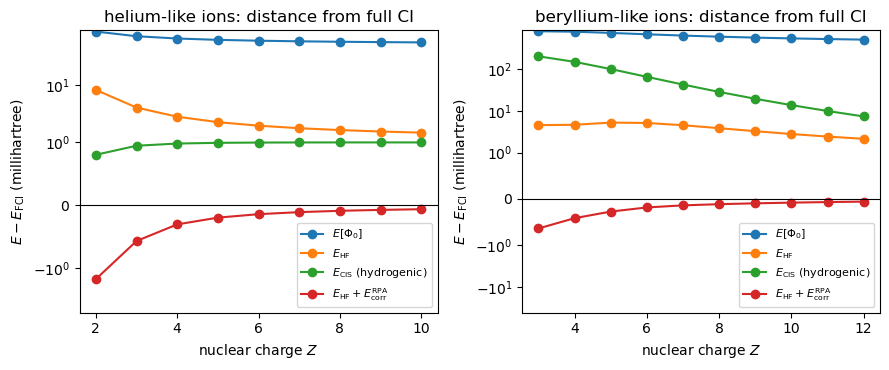

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.8))
for ax, (N, Zs, name) in zip(axes, ((2, range(2, 11), "helium-like"), (4, range(3, 13), "beryllium-like"))):
    rows = []
    for Z in Zs:
        atom = atoms.Atom(Z, N)
        H = atom.fock_space_hamiltonian()
        hf = atom.hartree_fock()
        res = atom.tda_rpa(hf)
        E_fci = atom.fci(H)[0][0]
        rows.append((Z, atom.reference_energy() - E_fci, hf["energy"] - E_fci,
                     atom.cis(H)[0][0] - E_fci, hf["energy"] + res["ecorr"] - E_fci, E_fci))
    rows = np.array(rows)
    print(f"{name}:  Z, E_FCI, and E - E_FCI for the reference, HF, CIS and HF+RPA (millihartree)")
    for row in rows:
        print(f"   {int(row[0]):3d} {row[5]:12.5f}   {1e3*row[1]:9.3f} {1e3*row[2]:9.3f} {1e3*row[3]:9.3f} {1e3*row[4]:9.3f}")
    for k, label in ((1, r"$E[\Phi_0]$"), (2, r"$E_{\rm HF}$"), (3, r"$E_{\rm CIS}$ (hydrogenic)"), (4, r"$E_{\rm HF}+E^{\rm RPA}_{\rm corr}$")):
        ax.plot(rows[:, 0], 1e3 * rows[:, k], "o-", label=label)
    ax.axhline(0.0, color="k", lw=0.8)
    ax.set_yscale("symlog", linthresh=1.0)
    ax.set_xlabel("nuclear charge $Z$")
    ax.set_ylabel(r"$E-E_{\rm FCI}$ (millihartree)")
    ax.set_title(f"{name} ions: distance from full CI")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()